# Phase 6 — Market Basket Analysis
## Retail Customer Analysis — UCI Online Retail II

**Goal of this phase:** discover which products are bought together, so the business can act on it
through cross-selling, bundling, and product placement. This is the shift from *who the customers
are* (Phases 3-5) to *what they buy together*.

**Method:** association-rule mining with the **Apriori** algorithm (cross-checked with FP-Growth),
producing rules of the form "customers who buy A also buy B", scored by:
- **Support** — how often the combination appears across all baskets.
- **Confidence** — of baskets containing A, the share that also contain B.
- **Lift** — how much more often A and B occur together than chance would predict. Lift > 1 means a
  genuine positive association; this is our primary ranking metric.

**Two scoping decisions, and why (these shape every result below):**
1. **Filter to the top-N products by frequency.** With 5,000+ distinct products the itemset space
   explodes combinatorially and Apriori becomes intractable. More importantly, rare products appear
   in too few baskets to produce *statistically reliable* rules — a pair seen 3 times isn't a
   pattern. Restricting to the most common products keeps the computation fast **and** ensures every
   rule rests on enough observations to be trustworthy.
2. **Use a moderate support floor, then tune.** Too low a floor returns thousands of niche, noisy
   rules; too high returns only the few most obvious pairs. We start at a moderate value, see how
   many rules come back, and adjust from there.

**Data source:** `transactions_clean` from PostgreSQL — the full sales table including guest
checkouts, because basket analysis works at the *invoice* level and does not need customer IDs.


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import getpass
import os
from pathlib import Path
from sqlalchemy import create_engine
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
os.makedirs(PROCESSED_PATH, exist_ok=True)

## 2. Load Transactions

We only need the invoice (which basket) and the product description (which item).

In [2]:
username = getpass.getuser()
engine = create_engine(f'postgresql+psycopg2://{username}@localhost:5432/retail_db', future=True)

df = pd.read_sql('SELECT invoice, description FROM transactions_clean', engine)
df = df.dropna(subset=['description'])
print(f'Loaded {len(df):,} item lines across {df["invoice"].nunique():,} invoices')
print(f'Distinct products: {df["description"].nunique():,}')

Loaded 1,003,340 item lines across 39,516 invoices
Distinct products: 5,377


## 3. Scoping Decision 1 — Keep the Top-N Products

We restrict to the most frequently purchased products. Rationale (see header): tractability plus
rule reliability. N is set here as a single knob so it is easy to tune.

In [3]:
# TUNABLE: number of most-frequent products to keep.
# Higher N = more products/rules but slower and noisier; lower N = faster, only core catalogue.
TOP_N = 120

top_products = df['description'].value_counts().head(TOP_N).index
df_top = df[df['description'].isin(top_products)]

print(f'Kept top {TOP_N} products')
print(f'Item lines retained: {len(df_top):,} ({len(df_top)/len(df)*100:.1f}% of all lines)')
print(f'Invoices represented: {df_top["invoice"].nunique():,}')

Kept top 120 products
Item lines retained: 188,696 (18.8% of all lines)
Invoices represented: 31,506


## 4. Build the Basket Matrix

We reshape into a grid: one row per invoice, one column per product, marked True if that product
was in the basket. We then keep only baskets with **2 or more items** — a single-item basket can't
form an association.

In [4]:
# One row per invoice, one column per product, True/False for presence in the basket
basket = (df_top.groupby(['invoice', 'description']).size()
                .unstack(fill_value=0) > 0)

# IMPORTANT compatibility step: force plain Python str column names.
# Newer mlxtend + numpy versions crash in association_rules when item labels are
# numpy string types; converting to plain str avoids that bug across versions.
basket.columns = [str(c) for c in basket.columns]

# Keep only multi-item baskets — single-item invoices cannot produce co-purchase rules
basket = basket[basket.sum(axis=1) >= 2]

print(f'Basket matrix: {basket.shape[0]:,} multi-item invoices x {basket.shape[1]} products')

Basket matrix: 25,814 multi-item invoices x 120 products


## 5. Scoping Decision 2 — Frequent Itemsets at a Moderate Support Floor

We run Apriori at a moderate minimum support. The printed count tells us whether to tune: too many
itemsets → raise the floor; too few → lower it.

In [5]:
# TUNABLE: minimum support. 0.02 = an itemset must appear in at least 2% of baskets.
# Raise for fewer/stronger itemsets; lower for more (and noisier) ones.
MIN_SUPPORT = 0.02

frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
print(f'Frequent itemsets found at support >= {MIN_SUPPORT}: {len(frequent_itemsets):,}')

# Cross-check with FP-Growth — a faster algorithm that should find the SAME itemsets.
# Agreement confirms the result is algorithm-independent, not an artifact.
fp_itemsets = fpgrowth(basket, min_support=MIN_SUPPORT, use_colnames=True)
print(f'FP-Growth itemsets: {len(fp_itemsets):,}  (matches Apriori: {len(frequent_itemsets) == len(fp_itemsets)})')

Frequent itemsets found at support >= 0.02: 237
FP-Growth itemsets: 237  (matches Apriori: True)


## 6. Generate Association Rules, Ranked by Lift

We keep only rules with **lift > 1** (genuine positive associations) and sort by lift, so the most
surprising, actionable co-purchases surface first.

In [6]:
# Build rules and rank by lift (our primary metric for 'surprising and actionable')
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rules with lift > 1: {len(rules):,}')
print(f'Of those, strong rules (confidence >= 0.5): {(rules["confidence"] >= 0.5).sum():,}')

Rules with lift > 1: 242
Of those, strong rules (confidence >= 0.5): 42


In [7]:
# Readable view of the strongest rules. Convert the frozenset antecedent/consequent to text.
def items_to_text(itemset):
    return ', '.join(sorted(itemset))

readable = rules.copy()
readable['if_basket_has'] = readable['antecedents'].apply(items_to_text)
readable['then_also_buys'] = readable['consequents'].apply(items_to_text)

readable[['if_basket_has', 'then_also_buys', 'support', 'confidence', 'lift']].head(15)

,if_basket_has,then_also_buys,support,confidence,lift
0,GREEN REGENCY TEACUP AND SAUCER,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",0.022,0.431,15.100
1,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",GREEN REGENCY TEACUP AND SAUCER,0.022,0.774,15.100
2,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.022,0.801,14.910
3,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.022,0.411,14.910
4,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.040,0.738,14.391
5,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.040,0.773,14.391
6,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER OWL DESIGN,0.025,0.609,13.230
7,HAND WARMER OWL DESIGN,HAND WARMER SCOTTY DOG DESIGN,0.025,0.546,13.230
8,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.032,0.629,13.075
9,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.032,0.674,13.075


## 7. Visualise the Top Rules

The strongest co-purchase associations by lift. Longer bars = pairs that occur together far more
than chance would predict.

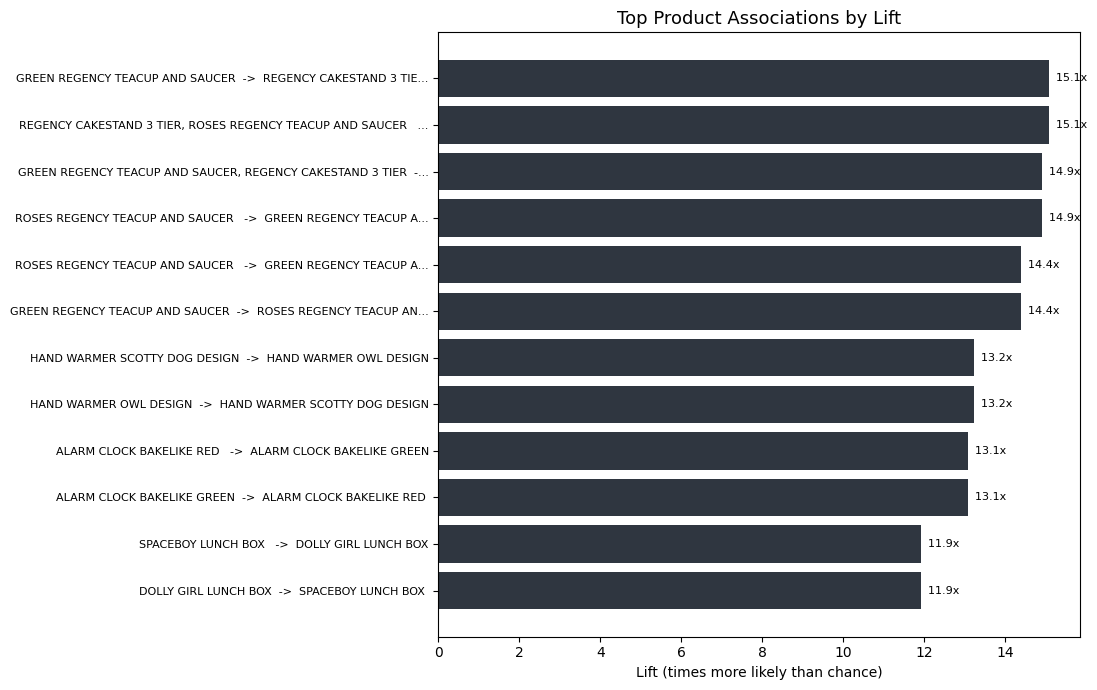

In [8]:
# Top 12 rules by lift, as readable 'A -> B' labels
topn = readable.head(12).iloc[::-1]
labels = [f"{a}  ->  {c}" for a, c in zip(topn['if_basket_has'], topn['then_also_buys'])]
# Truncate very long product-name pairs so the chart stays readable
labels = [(l[:60] + '...') if len(l) > 63 else l for l in labels]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(topn)), topn['lift'], color='#2f3640')
ax.set_yticks(range(len(topn)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Lift (times more likely than chance)')
ax.set_title('Top Product Associations by Lift', fontsize=13)
for i, v in enumerate(topn['lift']):
    ax.text(v, i, f'  {v:.1f}x', va='center', fontsize=8)
plt.tight_layout()
plt.show()

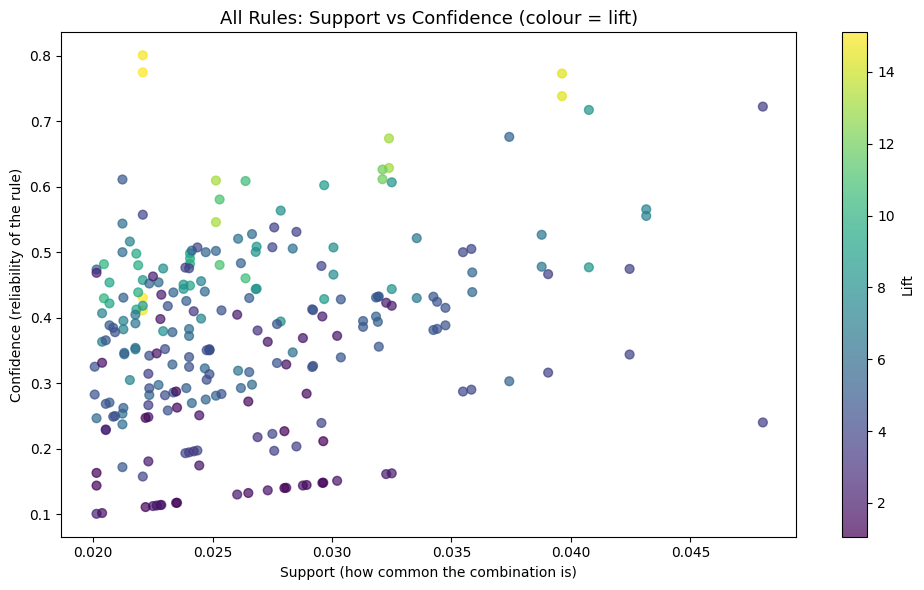

In [9]:
# Support vs confidence scatter, coloured by lift — the classic market-basket overview.
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(rules['support'], rules['confidence'],
                c=rules['lift'], cmap='viridis', s=40, alpha=0.7)
ax.set_xlabel('Support (how common the combination is)')
ax.set_ylabel('Confidence (reliability of the rule)')
ax.set_title('All Rules: Support vs Confidence (colour = lift)', fontsize=13)
plt.colorbar(sc, label='Lift')
plt.tight_layout()
plt.show()

## 8. Save Results

Save the rules to CSV and PostgreSQL for the Tableau dashboard. We store the readable text columns
so the dashboard can display product names directly.

In [10]:
# Keep the readable, dashboard-friendly columns
rules_out = readable[['if_basket_has', 'then_also_buys',
                      'support', 'confidence', 'lift']].copy()

rules_out.to_csv(PROCESSED_PATH + 'market_basket_rules.csv', index=False)
rules_out.to_sql('market_basket_rules', engine, if_exists='replace', index=False,
                 chunksize=5000, method='multi')
print(f'Saved market_basket_rules: {len(rules_out):,} rules')

Saved market_basket_rules: 242 rules


## 9. Phase 6 Summary

Using Apriori (cross-checked with FP-Growth) on the top products at a moderate support floor, we
surfaced the strongest co-purchase associations, ranked by lift. The scoping choices — top-N
products and a moderate support threshold — were made to keep the analysis both computationally
tractable and statistically reliable, and both are exposed as tunable knobs.

These rules are the basis for cross-selling, bundling, and product-placement decisions.

**Next — Phase 7: Tableau Dashboard.** We bring the whole project together into an interactive,
multi-page dashboard drawing on every table now in the database: clean transactions, cohorts, RFM
segments, CLV predictions, and these basket rules.
